In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

# Load the CIFAR-100 dataset
dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transforms.ToTensor())

# Get an image and label from the dataset
image, label = dataset[100]  # Index 0, you can change this to view different images

# Convert the image tensor to a numpy array and rearrange dimensions for matplotlib
image_np = image.permute(1, 2, 0).numpy()  # Change from (C, H, W) to (H, W, C)

# Display the image with matplotlib
plt.imshow(image_np)
plt.title(f"Label: {label} (Class Index)")
plt.axis('off')
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from model import LeNet5
from tqdm import tqdm

full_train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transforms.ToTensor())

train_size = 0.8  # 80% for training
val_size = 1 - train_size  # 20% for validation

train_dataset, val_dataset = random_split(full_train_dataset, (train_size, val_size))

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5(num_classes=100).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_loss, train_acc, eval_loss, eval_acc = model.fit(train_loader, 5, criterion, optimizer, device, val_dataset, save_every=2)


In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_hyperparameter_search_results(results_df: pd.DataFrame):
    """
    Visualizes hyperparameter search results using Seaborn.

    Args:
        results_df (pd.DataFrame): DataFrame containing hyperparameter combinations and metrics.

    Plots:
        - Pairplot: Relationships between hyperparameters and metrics.
        - Line/Scatter Plots: Individual metrics against a specific hyperparameter.
    """
    # Pairplot for an overview of relationships
    print("Generating pairplot...")
    sns.pairplot(results_df, diag_kind="kde", corner=True)
    plt.suptitle("Hyperparameter Search Results", y=1.02)
    plt.show()

    # Example 1: Validation accuracy vs learning rate
    if "lr" in results_df.columns:
        print("Plotting Validation Accuracy vs Learning Rate...")
        sns.scatterplot(x="lr", y="eval_acc", data=results_df)
        plt.title("Validation Accuracy vs Learning Rate")
        plt.xscale("log")
        plt.xlabel("Learning Rate (log scale)")
        plt.ylabel("Validation Accuracy")
        plt.show()

    # Example 2: Validation loss vs weight decay
    if "momentum" in results_df.columns:
        print("Plotting Validation Loss vs Weight Decay...")
        sns.scatterplot(x="momentum", y="eval_loss", data=results_df)
        plt.title("Validation Loss vs Weight Decay")
        plt.xscale("log")
        plt.xlabel("Weight Decay (log scale)")
        plt.ylabel("Validation Loss")
        plt.show()




def plot_2d_results(results_df, metric="eval_acc"):
    params = results_df.columns[:-1]

    fig, axss = plt.subplots(len(params), len(params), sharex="col", sharey="row")

    # fig.suptitle(metric)
    for i, (axs, x_param) in enumerate(zip(axss, params)):
        for j in range(len(params)): 
            ax = axs[j]
            if j >= i: 
                ax.set_visible(False)
            else: 
                y_param = params[j]
                heatmap_data = results_df.pivot_table(index=x_param, columns=y_param, values=metric)
                im = ax.imshow(heatmap_data, aspect="auto", cmap="viridis")
                ax.set_xlabel(y_param)
                ax.set_ylabel(x_param)
                ax.set_xticks(range(len(heatmap_data.columns)))
                ax.set_xticklabels(heatmap_data.columns, rotation=90)
                ax.set_yticks(range(len(heatmap_data.index)))
                ax.set_yticklabels(heatmap_data.index)


def plot_1d_results(results_df: pd.DataFrame, metric="eval_loss"):
    params = results_df.iloc[:, :-2]

    fig, axs = plt.subplots(len(params.columns)) 

    for ax, col in zip(axs, params):
        ax.scatter(params[col], results_df[metric])
        ax.set_xlabel(col)
        ax.grid()
    fig.supylabel(metric)


a = pd.read_csv("hyperparameter_results.csv")


In [62]:
a.sort_values("eval_loss", ascending=False).iloc[0]

lr           0.001067
momentum     0.359159
eval_loss    4.605182
eval_acc     0.012801
Name: 3, dtype: float64

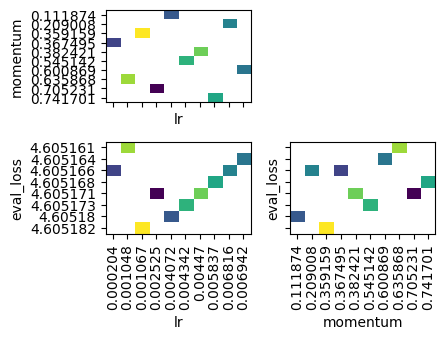

In [59]:
plot_2d_results(a)
plt.tight_layout()


In [ ]:
plt.imshow()

In [ ]:
a = np.array([(0, 1), (10, 20)])

for x in a:
    print(x) 

In [ ]:
import numpy as np
for i in itertools.product(np.linspace(0, 1, 10), np.linspace(10, 100, 10)):
    print(i)

In [ ]:
import matplotlib.pyplot as plt

def plot_metric(metric, **kwargs):
    plt.plot(range(len(metric)), metric, **kwargs)
    plt.xlabel("Epochs")
    plt.grid(True)


plot_metric(train_loss, marker="x")
plot_metric(eval_loss)
plt.ylabel("Loss")

In [ ]:
import main

main.main(2)

In [ ]:
def split_N_ways(train_data, N, random_seed=None):
    if random_seed is not None:
        random_seed = torch.Generator().manual_seed(random_seed)

    lengths = [len(train_data) / N] * N

    return random_split(train_data, lengths, random_seed)

def synchronize_models(models: list[torch.nn.Module]):
    #TODO
    pass

In [ ]:
# testing
test_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transforms.ToTensor())


test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

model.evaluate(model, test_loader, device)